In [2]:
import numpy as np
import matplotlib.pyplot as plt
import re
import os
from datetime import datetime
from scipy.optimize import curve_fit, fsolve
# directory_path = 'Z:/Lab Data/Qudit_Ramsey_raw_data/Raw_data_PD/'
directory_path = 'Z:\Lab Data\Qudit_Ramsey_raw_data\Line_signal_compensation_data'

# Fixed frequency: 2π
def sine_function(t, A, phi, offset):
    return A * np.cos(2 * np.pi/10 * t + phi) + offset

def combined_decay(t, A, T2_G, T2_L):
    gaussian_decay = np.exp(-(t / T2_G)**2)
    lorentzian_decay = np.exp(-t / T2_L)
    return A * gaussian_decay * lorentzian_decay

def parse_filename(filename):
    pattern = (
        r"Ramsey_qubit_\[(-?\d+),(-?\d+),(-?\d+)\]_LTWaitTime(\d+(?:\.\d+)?)us_comp_False_(\d{8})_(\d{4})_(\d{1}|\d{2}).txt"
    )
    match = re.search(pattern, filename)
    # print(match)
    if match:
        m = int(match.group(1))
        F = int(match.group(2))
        mF = int(match.group(3))
        wait_time = float(match.group(4))
        date_str = match.group(5) + match.group(6)  # "YYYYMMDDHHMM"
        date_time = datetime.strptime(date_str, '%Y%m%d%H%M')
        return (m, F, mF, wait_time, date_time)
    else:
        return (None, None, None, None, None)

def search_files_by_transitions(directory, target_transition, target_date_times=None):
    wait_time_list = []
    raw_file_paths_list = []
    ref_freq_list = []
    final_params = (None, None, None)
    for filename in os.listdir(directory):
        if filename.startswith('Ramsey_qubit'):
            (m, F, mF, wait_time, date_time) = parse_filename(filename)
            if None in (m, F, mF, wait_time, date_time):
                continue
            if (m, F, mF) == target_transition:
                if target_date_times and date_time not in target_date_times:
                    continue  # Skip if date_time is not in the target list
                final_params = (m, F, mF)
                file_path = os.path.join(directory, filename)
                raw_data_filenames = extract_raw_data_filenames(file_path)
                ref_freqs = extract_two_frequencies(file_path)
                Z_drive_raw_data = 'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data\\'
                raw_data_filepaths = [os.path.join(Z_drive_raw_data, raw_filename) for raw_filename in raw_data_filenames]
                wait_time_list.append(wait_time)
                raw_file_paths_list.append(raw_data_filepaths)
                ref_freq_list.append(ref_freqs)
    return wait_time_list, raw_file_paths_list, final_params, ref_freq_list

def extract_raw_data_filenames(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    raw_data_filenames_line = lines[-1].strip()
    raw_data_filenames = [
        name.strip().strip("'\"") for name in raw_data_filenames_line.strip('[]').split(',')
    ]
    return raw_data_filenames

import ast

def extract_two_frequencies(file_path):

    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            s = line.strip()
            if not (s.startswith("[") and s.endswith("]")):
                continue

            try:
                val = ast.literal_eval(s)
            except Exception:
                continue

            # We want exactly two numeric values
            if (
                isinstance(val, list)
                and len(val) == 2
                and all(isinstance(x, (int, float)) for x in val)
            ):
                return [float(val[0]), float(val[1])]

    raise ValueError(f"Could not find a 2-number frequency list in {file_path}")


if __name__ == "__main__":
    target_transition = (-1, 4, -3)  # Replace with desired values

    # target_date_times = {datetime(2025, 11, 26, 16, 48), datetime(2025, 11, 26, 20, 41),datetime(2025, 11, 26, 23, 35)} # Comp False
    # target_date_times = {datetime(2025, 11, 27, 0, 27)} # Comp True
    # target_date_times = {datetime(2025, 12, 6, 21, 46)} # Comp False
    # target_date_times = {datetime(2025, 12, 7, 18, 18), datetime(2025, 12, 7, 18, 55), datetime(2025, 12, 7, 23, 54)} # Comp False complete line signal 20251207
    # target_date_times = {datetime(2026, 1, 14, 19, 20), datetime(2026, 1, 14, 21, 27)}
    target_date_times = {datetime(2026, 1, 15, 13, 48), datetime(2026, 1, 15, 16, 13), datetime(2026, 1, 15, 21, 42)}#, datetime(2026, 1, 15, 21, 20)} no COMP
    # target_date_times = {datetime(2026, 1, 16, 8, 41), datetime(2026, 1, 16, 10, 19), datetime(2026, 1, 16, 11, 9), datetime(2026, 1, 16, 13, 4)} # no comp
    # target_date_times = {datetime(2026, 1, 20, 13, 14)} # with fixed wait after LT of 700us and no comp
    # target_date_times = {datetime(2026, 1, 20, 14, 50), datetime(2026, 1, 20, 15, 59)} # with fixed wait after LT of 700us and no comp
    # target_date_times = {datetime(2026, 1, 20, 16, 26), datetime(2026, 1, 20, 16, 45), datetime(2026, 1, 20, 14, 50), datetime(2026, 1, 20, 15, 59)} # with fixed wait after LT of 700us and no comp
    # target_date_times = {datetime(2026, 1, 20, 17, 18), datetime(2026, 1, 20, 17, 30)}
    target_transition = (0,2,0)
    target_date_times = {datetime(2026, 1, 28, 13, 33)}
    wait_time_list, raw_file_paths_list, final_params, ref_freq_list = search_files_by_transitions(directory_path, target_transition, target_date_times)
    m, F, mF = final_params
    print(f"Parameters: m={m}, F={F}, mF={mF}")
    print("\nWait times and corresponding raw data file paths:")
    for wt, fp_list, f0_f1 in zip(wait_time_list, raw_file_paths_list, ref_freq_list):
        print(f"\nWait time: {wt} us, f0, f1 = {f0_f1}")
        
        for fp in fp_list:
            print(f"  {fp}")


Parameters: m=0, F=2, mF=0

Wait times and corresponding raw data file paths:

Wait time: 100.0 us, f0, f1 = [546.1017643639983, 623.8984934452202]
  Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_copied\\2026\\2026_01\\2026_01_28\\qudit_ramsey_scan_bused_352
  Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_copied\\2026\\2026_01\\2026_01_28\\qudit_ramsey_scan_bused_353
  Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_copied\\2026\\2026_01\\2026_01_28\\qudit_ramsey_scan_bused_354
  Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_copied\\2026\\2026_01\\2026_01_28\\qudit_ramsey_scan_bused_355
  Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_copied\\2026\\2026_01\\2026_01_28\\qudit_ramsey_scan_bused_356
  Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_copied\\2026\\2026_01\\2026_01_28\\qudit_ramsey_scan_bused_357
  Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_copied\\2026\\2026_01\\2026_01_28\\qudit_ramsey_scan_bused_358
  Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_copied\\2026\\2026_01\\2026

In [3]:
import numpy as np
import json

# --------------------------------
# Existing Functions (Unchanged)
# --------------------------------

def get_shelving_threshold(counts):
    data_sorted = np.sort(counts, axis=None)
    # Truncate outliers at the start and end
    data_sorted = data_sorted[100:-100]
    if len(data_sorted) > 1000:
        data_sorted = data_sorted[0:-1:round(data_sorted.size / (len(counts) * 0.0250167))]
    data_sorted_diff = data_sorted[1:-1] - data_sorted[0:-2]
    data_diff_max = max(data_sorted_diff)
    data_diff_maxind = np.argmax(data_sorted_diff)
    threshold = data_diff_max / 2 + data_sorted[data_diff_maxind]
    return threshold, data_sorted

def process_raw_data_files(raw_data_filepaths):
    arrays = []
    # Read and process the data from all raw data files
    for file_path in raw_data_filepaths:
        with open(file_path, 'r') as file:
            for line in file:
                data = json.loads(line)
                arrays.append(data[0]["0"])
    # Convert to numpy array
    hist_data = np.array(arrays)
    
    # Flatten the hist_data and compute shelving threshold
    flat_hist_data = hist_data.flatten()
    threshold, _ = get_shelving_threshold(flat_hist_data)

    # Prepare for further processing (3D array)
    arrays_3d = []
    for file_path in raw_data_filepaths[:]:
        arrays = []
        with open(file_path, 'r') as file:
            for line in file:
                data = json.loads(line)
                arrays.append(data[0]["0"][:])
        if len(arrays) == 0:
            arrays = list(np.full((100, 4), 40))  # fallback if no data
        arrays_3d.append(arrays)

    for k, file_path in enumerate(raw_data_filepaths):
        arrays = []
        with open(file_path, 'r') as f:
            for line in f:
                data = json.loads(line)
                arrays.append(data[0]["0"])
        if len(arrays) == 0:
            print("EMPTY:", file_path)
            continue

        widths = [len(x) for x in arrays if hasattr(x, "__len__")]
        print(k, os.path.basename(file_path), "min/max width:", min(widths), max(widths))
        if min(widths) != max(widths) or max(widths) != 2:
            print("   >>> CHECK THIS FILE:", file_path)



    bool_array = np.array(arrays_3d) > threshold
    print(bool_array.shape)
    result_matrix = np.full((10,250,3), False, dtype=bool)
    # Identify the first occurrence of shelving (True value)
    for matrix_index in range(bool_array.shape[0]):
        for row_index in range(bool_array.shape[1]):
            true_indices = np.where(bool_array[matrix_index, row_index, :])
            # print(bool_array[matrix_index, row_index, :])
            # if true_indices[0].size > 0:
            #     first_true_index = true_indices[0]
            #     # We exclude cases where the first-true index is 0 or 1
            #     if first_true_index[0] != 0:
            #         # print(first_true_index)
            #         result_matrix[matrix_index, row_index, first_true_index[0]] = True
            data_bool = bool_array[matrix_index, row_index, :]
            if data_bool[0] == False:
                if data_bool[1] == True:
                    result_matrix[matrix_index, row_index, 1] = True
                if data_bool[1] == False:
                    result_matrix[matrix_index, row_index, 2] = True

    # Filter data and compute percentages used
    filtered_data_array = []
    percentage_data_used = []
    num_points = bool_array.shape[0]  # Determine the number of data points
    # print(result_matrix)
    for i in range(num_points):
        data = result_matrix[i]
        rows_with_any_true = data.any(axis=1)
        filtered_data = data[rows_with_any_true]
        filtered_data_array.append(filtered_data)
        percentage_data_used.append(filtered_data.shape[0] / data.shape[0])

    # Compute ket data by averaging the filtered data
    def find_errors(num_SD, full_data_array, exp_num):
        upper_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
                       (1 + (num_SD**2 / exp_num))) + np.sqrt(
                           ((full_data_array *
                             (1 - full_data_array) * num_SD**2) / exp_num) +
                           (num_SD**4 / (4 * exp_num**2))
                       ) / (1 + (num_SD**2 / exp_num))

        lower_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
                       (1 + (num_SD**2 / exp_num))) - np.sqrt(
                           ((full_data_array *
                             (1 - full_data_array) * num_SD**2) / exp_num) +
                           (num_SD**4 / (4 * exp_num**2))
                       ) / (1 + (num_SD**2 / exp_num))

        return lower_error, upper_error

    ket_data = []
    exp_num_list = []
    for filtered_data in filtered_data_array:
        # Average across the 3rd dimension's index=2
        # print(filtered_data)
        ket_data.append(np.mean(filtered_data, axis=0)[1])
        exp_num_list.append(len(filtered_data))
    print(exp_num_list)
    lower_error, upper_error = find_errors(1, np.array(ket_data), np.array(exp_num_list))
    
    return ket_data, lower_error, upper_error


# ------------------------------------------------
# New Function Using Parallel Lists (NOT a dict)
# ------------------------------------------------
def process_all_wait_times_in_lists(wait_time_list, raw_file_paths_list):
    """
    Instead of passing a dictionary {wait_time: [file1, file2, ...]},
    we pass in two parallel lists:
      1) wait_time_list[i] 
      2) raw_file_paths_list[i]

    We will return four separate lists:
      - processed_wait_times[i]
      - ket_data_list[i]
      - lower_error_list[i]
      - upper_error_list[i]

    Each index i in these return lists corresponds to the same data set.
    """
    processed_wait_times = []
    ket_data_list = []
    lower_error_list = []
    upper_error_list = []
    
    # Iterate over each index in the parallel lists
    for i, wait_time in enumerate(wait_time_list):
        # Fetch corresponding raw data file paths
        raw_data_filepaths = raw_file_paths_list[i]

        # Process the raw data
        ket_data, lower_error, upper_error = process_raw_data_files(raw_data_filepaths)

        # Store results in the four lists
        processed_wait_times.append(wait_time)

        # ket_data is already a list of floats
        # lower_error and upper_error are arrays (same shape as ket_data)
        # The original code does:
        #   final_lower = ket_data - lower_error
        #   final_upper = upper_error - ket_data
        # so we replicate that logic
        ket_data_arr = np.array(ket_data)
        final_lower_error = np.abs(ket_data_arr - np.array(lower_error))
        final_upper_error = np.abs(np.array(upper_error) - ket_data_arr)

        ket_data_list.append(ket_data)
        lower_error_list.append(final_lower_error)
        upper_error_list.append(final_upper_error)

    return processed_wait_times, ket_data_list, lower_error_list, upper_error_list

wait_time_list, raw_file_paths_list = zip(
    *sorted(zip(wait_time_list, raw_file_paths_list), key=lambda x: x[0])
)

# Convert back to lists if needed
wait_time_list = list(wait_time_list)
raw_file_paths_list = list(raw_file_paths_list)

(
    processed_wait_times, 
    ket_data_list, 
    lower_error_list, 
    upper_error_list
) = process_all_wait_times_in_lists(wait_time_list, raw_file_paths_list)

# Printing example output
print("\nProcessed Data in Parallel Lists:")
for wt, ket_vals, le_vals, ue_vals in zip(processed_wait_times, ket_data_list, lower_error_list, upper_error_list):
    print(f"\nWait Time: {wt} us")
    print(f"Ket Data (list): {ket_vals}")
    print(f"Lower Error (array): {le_vals}")
    print(f"Upper Error (array): {ue_vals}")


0 qudit_ramsey_scan_bused_352 min/max width: 2 2
1 qudit_ramsey_scan_bused_353 min/max width: 2 2
2 qudit_ramsey_scan_bused_354 min/max width: 2 2
3 qudit_ramsey_scan_bused_355 min/max width: 2 2
4 qudit_ramsey_scan_bused_356 min/max width: 2 2
5 qudit_ramsey_scan_bused_357 min/max width: 2 2
6 qudit_ramsey_scan_bused_358 min/max width: 2 2
7 qudit_ramsey_scan_bused_359 min/max width: 2 2
8 qudit_ramsey_scan_bused_360 min/max width: 2 2
9 qudit_ramsey_scan_bused_361 min/max width: 2 2
(10, 100, 2)
[95, 95, 99, 99, 98, 99, 98, 98, 98, 98]
0 qudit_ramsey_scan_bused_364 min/max width: 2 2
1 qudit_ramsey_scan_bused_365 min/max width: 2 2
2 qudit_ramsey_scan_bused_366 min/max width: 2 2
3 qudit_ramsey_scan_bused_367 min/max width: 2 2
4 qudit_ramsey_scan_bused_368 min/max width: 2 2
5 qudit_ramsey_scan_bused_369 min/max width: 2 2
6 qudit_ramsey_scan_bused_370 min/max width: 2 2
7 qudit_ramsey_scan_bused_371 min/max width: 2 2
8 qudit_ramsey_scan_bused_372 min/max width: 2 2
9 qudit_ramsey_

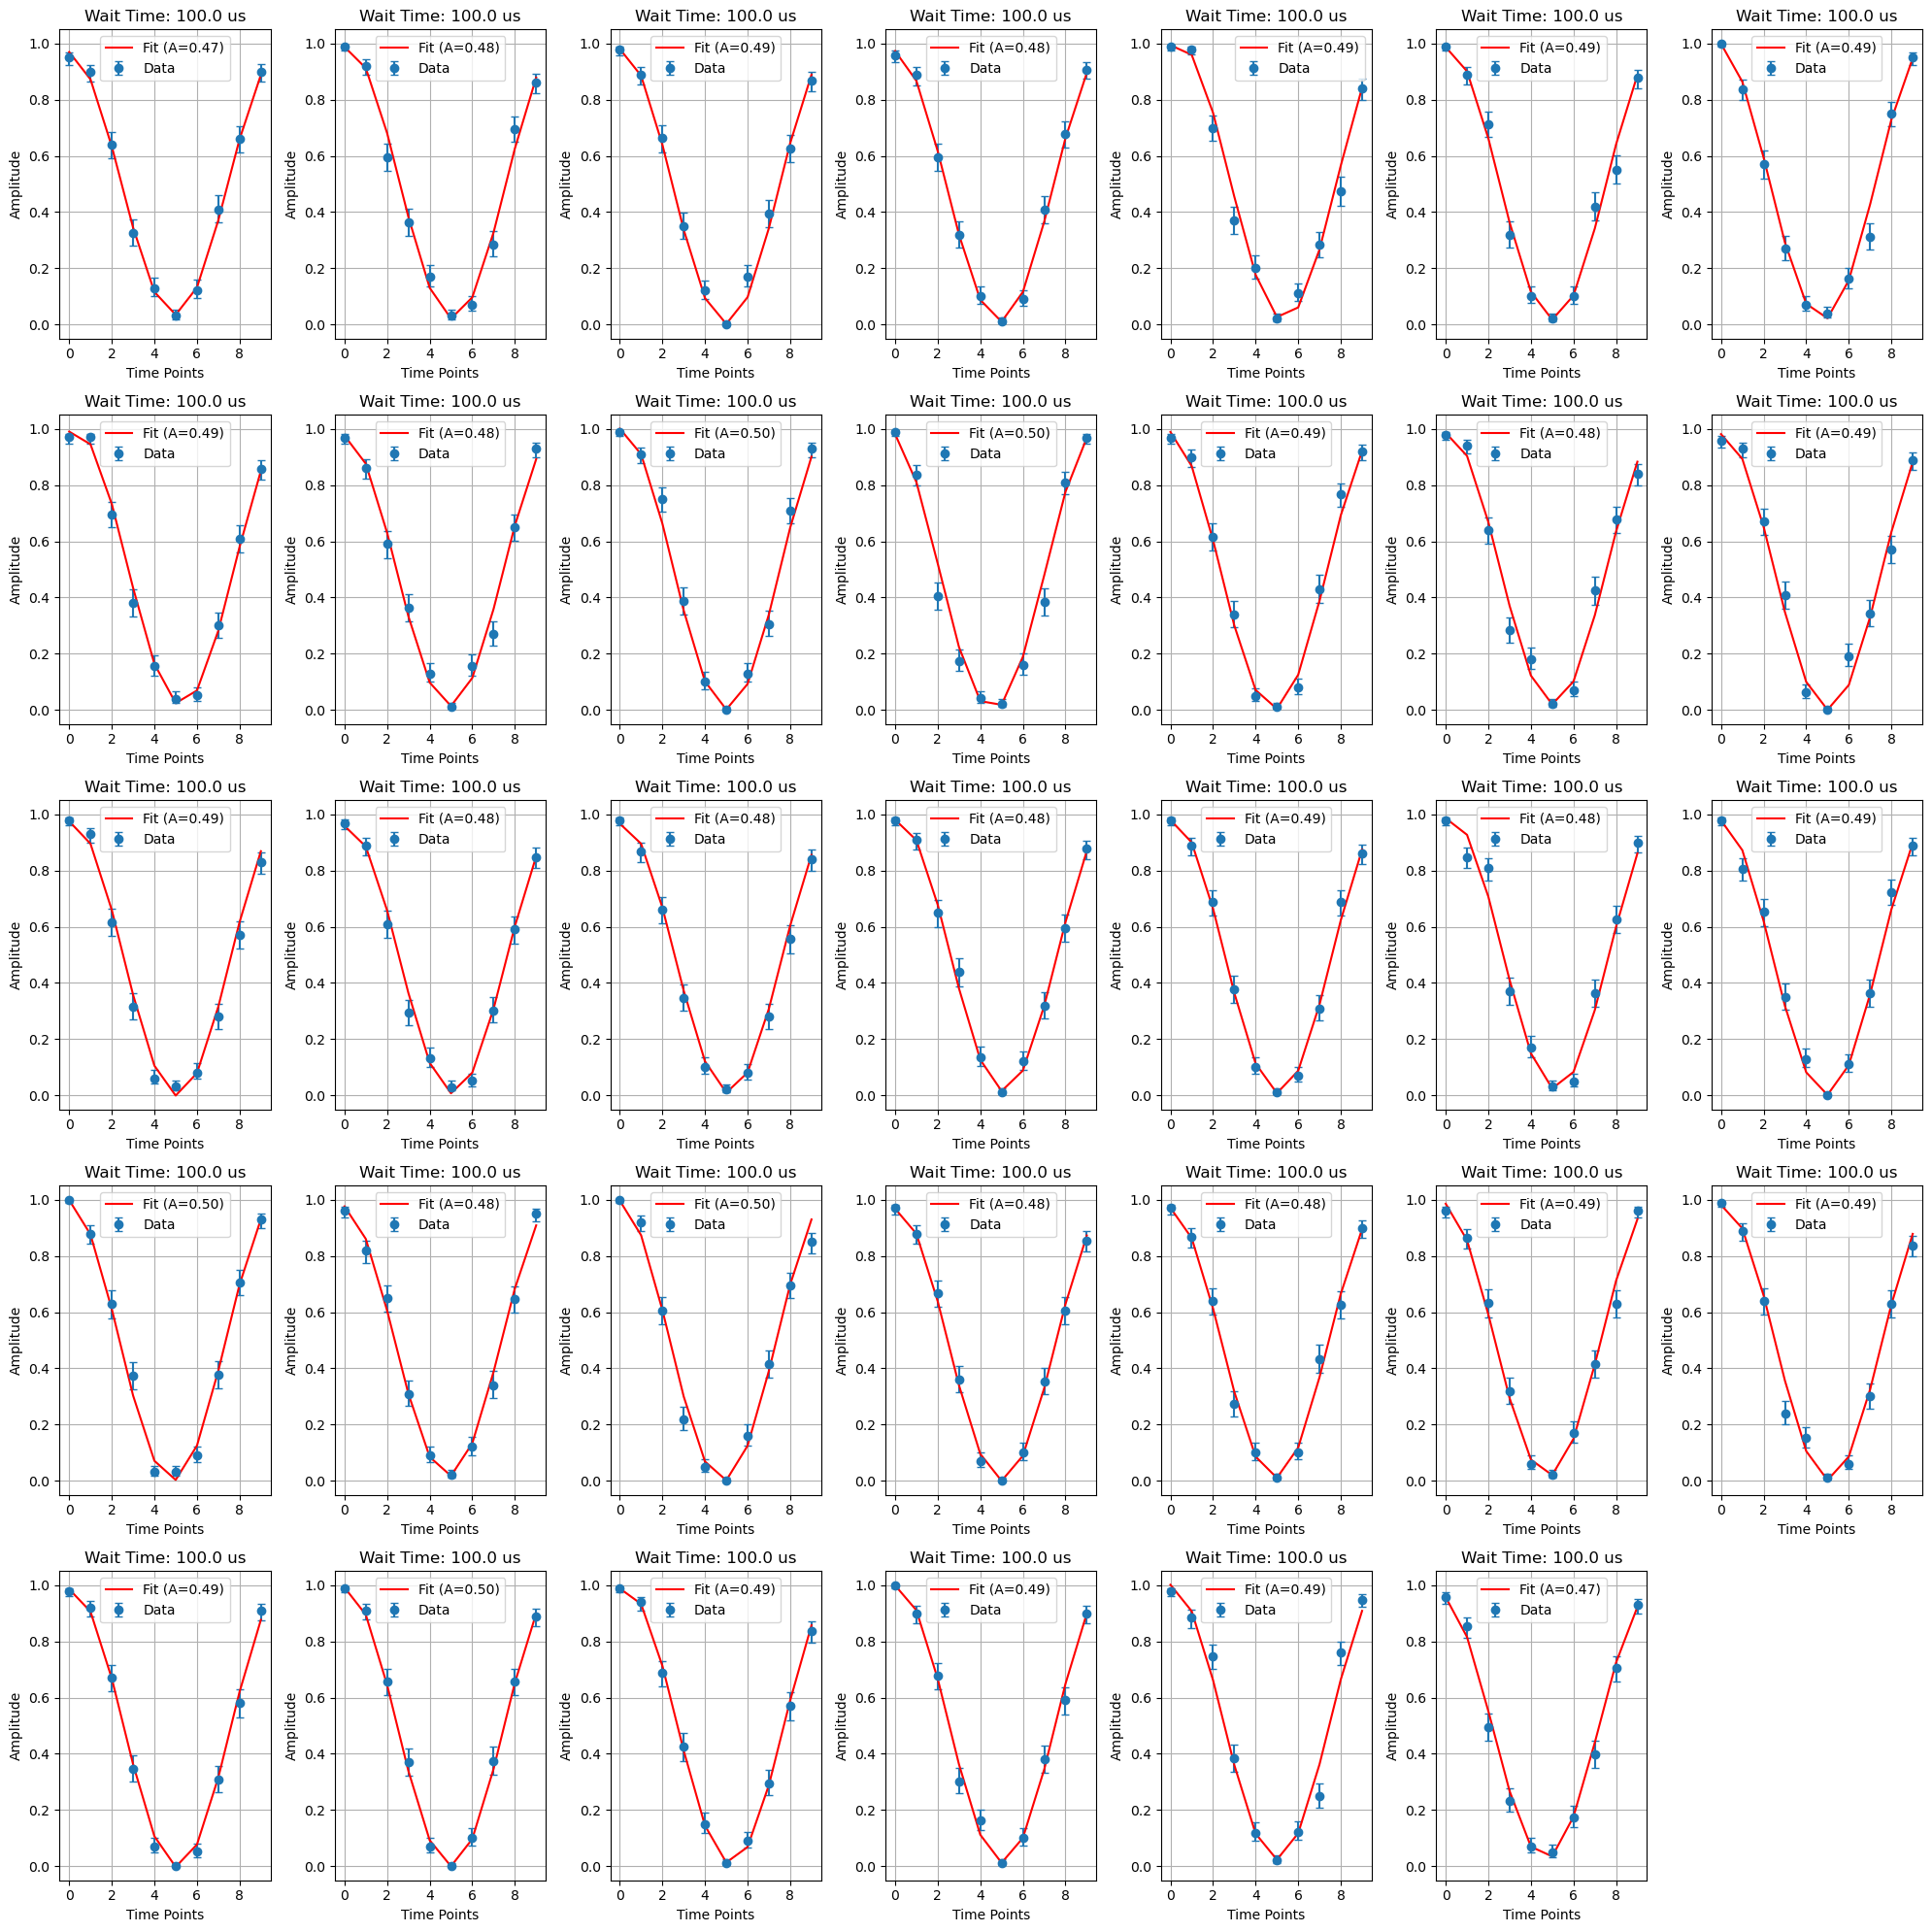


Fitted Results (Lists):
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.470, -0.195, 0.496
  Amplitude (2*|A|) = 0.940 ± 0.023
  Phase = -0.195 ± 0.039
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.489, -0.002, 0.512
  Amplitude (2*|A|) = 0.978 ± 0.018
  Phase = -0.002 ± 0.035
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.494, 0.019, 0.506
  Amplitude (2*|A|) = 0.988 ± 0.011
  Phase = 0.019 ± 0.037
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.492, 0.132, 0.501
  Amplitude (2*|A|) = 0.984 ± 0.015
  Phase = 0.132 ± 0.037
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.496, -0.008, 0.496
  Amplitude (2*|A|) = 0.992 ± 0.011
  Phase = -0.008 ± 0.035
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.495, 0.051, 0.492
  Amplitude (2*|A|) = 0.990 ± 0.013
  Phase = 0.051 ± 0.034
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.490, 0.034, 0.492
  Amplitude (2*|A|) = 0.980 ± 0.014
  Phase = 0.034 ± 0.036
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.487, -0.130, 0.503
  Am

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# # Fixed frequency: 2π
# def sine_function(t, A, phi, offset):
#     return A * np.cos(2 * np.pi/10 * t + phi) + offset

# def fit_sine_curve(ket_data, lower_error, upper_error):
#     if len(ket_data) == 5:
#         t = 2*np.arange(len(ket_data))
#     else:
#         t = np.arange(len(ket_data))
#     valid_indices = ~np.isnan(ket_data) & ~np.isnan(lower_error) & ~np.isnan(upper_error)
#     t_valid = t[valid_indices]
#     ket_data_valid = np.array(ket_data)[valid_indices]
#     lower_error_valid = np.array(lower_error)[valid_indices]
#     upper_error_valid = np.array(upper_error)[valid_indices]

#     sigma = (upper_error_valid + lower_error_valid) / 2.0
#     if np.any(sigma <= 0):
#         nonzero = sigma[sigma > 0]
#         replacement = np.min(nonzero) if len(nonzero) > 0 else 1.0
#         sigma[sigma <= 0] = replacement

#     initial_guess = [
#         (np.max(ket_data_valid) - np.min(ket_data_valid))/2,
#         0,
#         np.mean(ket_data_valid)
#     ]
#     try:
#         params, covariance = curve_fit(
#             sine_function,
#             t_valid,
#             ket_data_valid,
#             p0=initial_guess,
#             sigma=sigma,
#             absolute_sigma=True, maxfev=10000
#         )
#         if covariance is not None:
#             errors = np.sqrt(np.diag(covariance))
#             errors = [err if np.isfinite(err) else None for err in errors]
#         else:
#             errors = [None] * len(params)

#         return params, errors
#     except RuntimeError:
#         return None, None

def sine_function(t, A, phi, offset):
    return A * np.cos(2 * np.pi/10 * t - phi) + offset

def fit_sine_curve(ket_data, lower_error, upper_error):
    if len(ket_data) == 5:
        t = 2*np.arange(len(ket_data))
    else:
        t = np.arange(len(ket_data))
    valid_indices = ~np.isnan(ket_data) & ~np.isnan(lower_error) & ~np.isnan(upper_error)
    t_valid = t[valid_indices]
    ket_data_valid = np.array(ket_data)[valid_indices]
    lower_error_valid = np.array(lower_error)[valid_indices]
    upper_error_valid = np.array(upper_error)[valid_indices]

    sigma = (upper_error_valid + lower_error_valid) / 2.0
    if np.any(sigma <= 0):
        nonzero = sigma[sigma > 0]
        replacement = np.min(nonzero) if len(nonzero) > 0 else 1.0
        sigma[sigma <= 0] = replacement

    A0 = (np.max(ket_data_valid) - np.min(ket_data_valid))/2
    A0 = np.clip(A0, 0.0, 0.5)
    initial_guess = [0.44, 0.004, 0.46]

    try:
        params, covariance = curve_fit(
            sine_function,
            t_valid,
            ket_data_valid,
            p0=initial_guess,
            sigma=sigma,
            absolute_sigma=True,
            maxfev=10000,
            bounds=([0.0, -np.pi, 0], [0.5, np.pi, 1])
        )
        if covariance is not None:
            errors = np.sqrt(np.diag(covariance))
            errors = [err if np.isfinite(err) else None for err in errors]
        else:
            errors = [None] * len(params)
        return params, errors
    except RuntimeError:
        return None, None


def fit_all_wait_times_to_sine_in_lists(wait_time_list,
                                        ket_data_list,
                                        lower_error_list,
                                        upper_error_list):
    fit_wait_times_list = []
    fit_params_list = []
    fit_amplitudes_list = []
    fit_amplitude_errors_list = []
    fit_phases_list = []
    fit_phase_errors_list = []
    
    for i in range(len(wait_time_list)):
        wt = wait_time_list[i]
        kd = ket_data_list[i]
        le = lower_error_list[i]
        ue = upper_error_list[i]
        
        if len(kd) > 4:
            params, errors = fit_sine_curve(kd, le, ue)
            if params is not None and errors is not None and errors[0] is not None:
                A, phi, offset = params
                amplitude = 2.0 * abs(A)
                amplitude_error = 2.0 * errors[0] if errors[0] is not None else None
                phase_error = errors[1]

                fit_wait_times_list.append(wt)
                fit_params_list.append(params)
                fit_amplitudes_list.append(amplitude)
                fit_amplitude_errors_list.append(amplitude_error)
                fit_phases_list.append(phi)
                fit_phase_errors_list.append(phase_error)
        else:
            fit_wait_times_list.append(wt)
            fit_params_list.append([None, None, None])
            fit_amplitudes_list.append(None)
            fit_amplitude_errors_list.append(None)
            fit_phases_list.append(None)
            fit_phase_errors_list.append(None)
    return (
        fit_wait_times_list,
        fit_params_list,
        fit_amplitudes_list,
        fit_amplitude_errors_list,
        fit_phases_list,
        fit_phase_errors_list
    )

def plot_sine_fits_in_lists(wait_time_list,
                            ket_data_list,
                            lower_error_list,
                            upper_error_list,
                            fit_wait_times_list,
                            fit_params_list):
    num_plots = len(wait_time_list)
    num_columns = 7
    num_rows = (num_plots + num_columns - 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 4 * num_rows))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    for i in range(num_plots):
        wt = wait_time_list[::-1][i]
        kd = ket_data_list[::-1][i]
        le = lower_error_list[::-1][i]
        ue = upper_error_list[::-1][i]
        
        t = np.arange(len(kd))
        ax = axes[i]
        ax.errorbar(
            t,
            kd,
            yerr=[abs(le), abs(ue)],
            fmt='o',
            label='Data',
            capsize=3
        )
        
        if wt in fit_wait_times_list:
            j = fit_wait_times_list[::-1].index(wt)
            A, phi, offset = fit_params_list[::-1][i]
            if A is not None:
                fit_curve = sine_function(t, A, phi, offset)
                ax.plot(t, fit_curve, color='red', label=f'Fit (A={A:.2f})')

        ax.set_title(f'Wait Time: {wt} us')
        ax.set_xlabel('Time Points')
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel('Amplitude')
        ax.grid()
        ax.legend()
    
    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.savefig('laser_noise_phase_scans.png', dpi=300)
    plt.show()

(
    fit_wait_times_list,
    fit_params_list,
    fit_amplitudes_list,
    fit_amplitude_errors_list,
    fit_phases_list,
    fit_phase_errors_list
) = fit_all_wait_times_to_sine_in_lists(
    wait_time_list,
    ket_data_list,
    lower_error_list,
    upper_error_list
)

plot_sine_fits_in_lists(
    wait_time_list,
    ket_data_list,
    lower_error_list,
    upper_error_list,
    fit_wait_times_list,
    fit_params_list
)

print("\nFitted Results (Lists):")
for i, wt in enumerate(fit_wait_times_list):
    A, phi, offset = fit_params_list[i]
    amp = fit_amplitudes_list[i]
    amp_err = fit_amplitude_errors_list[i]
    phase = fit_phases_list[i]
    phase_err = fit_phase_errors_list[i]
    print(f"Wait Time: {wt} us")
    print(f"  Params (A, phi, offset) = {A:.3f}, {phi:.3f}, {offset:.3f}")
    print(f"  Amplitude (2*|A|) = {amp:.3f} ± {amp_err:.3f}")
    print(f"  Phase = {phase:.3f} ± {phase_err:.3f}")


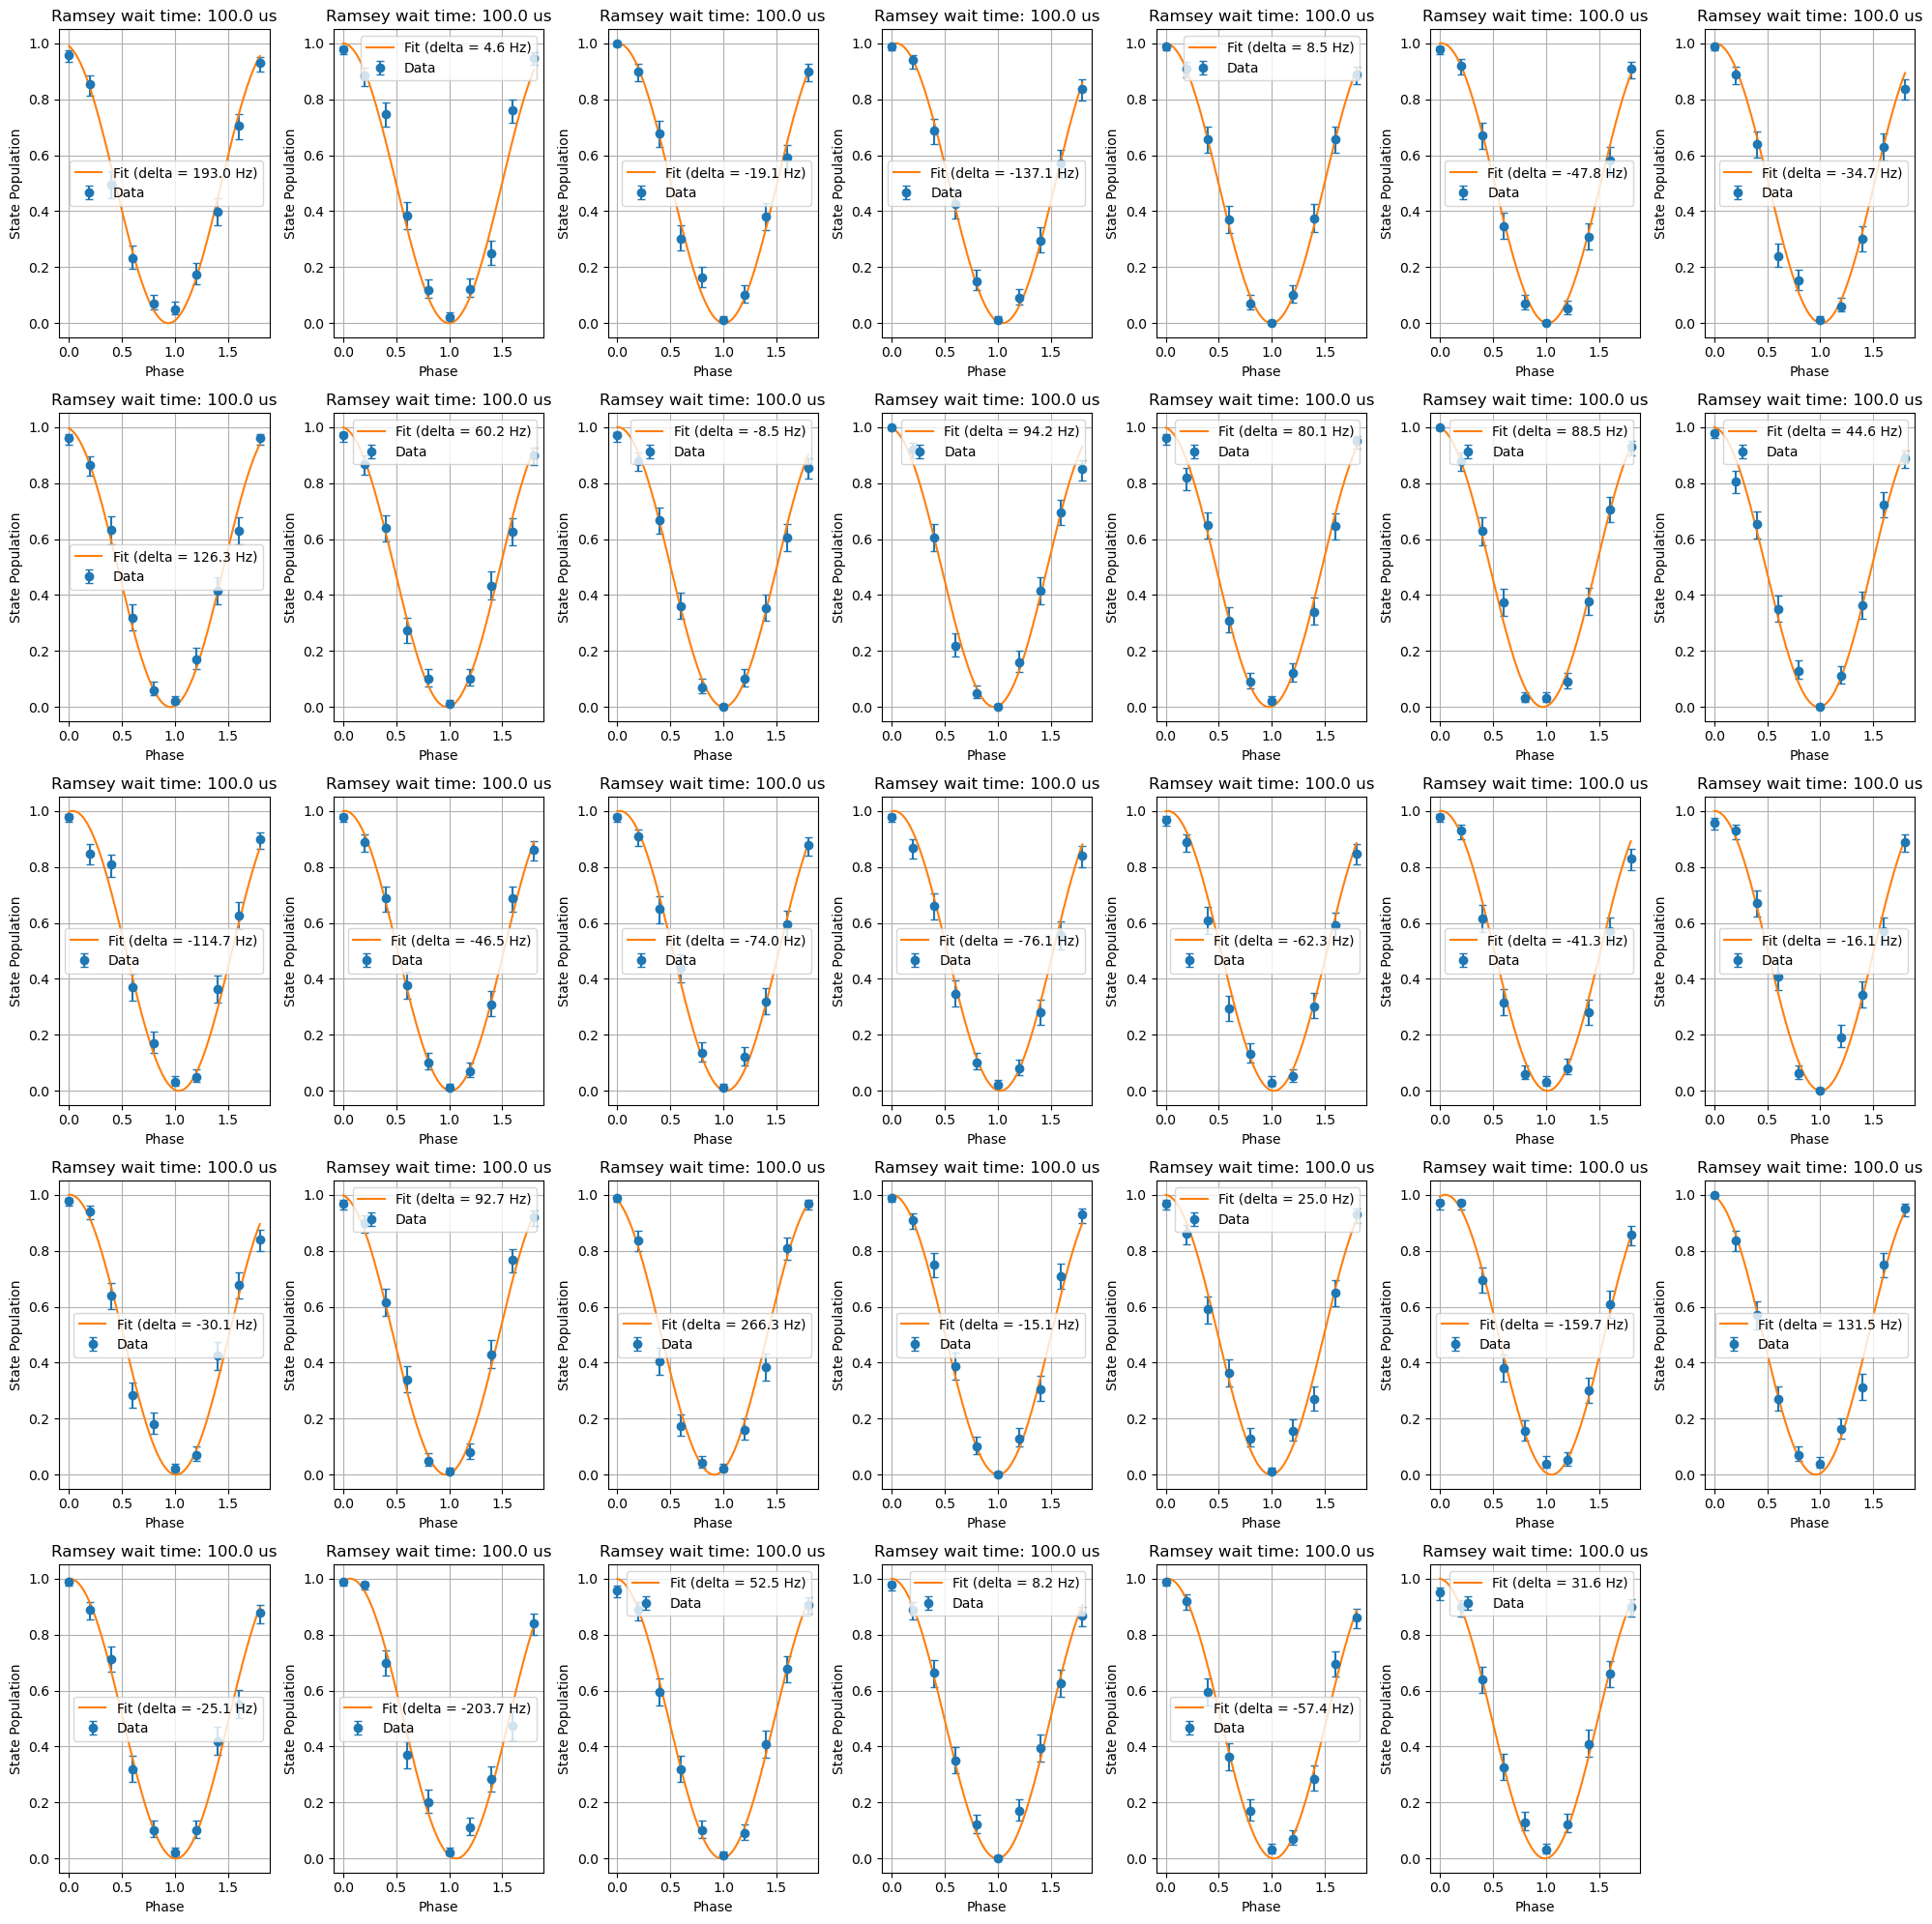


Fitted Detunings:
f0 = 546.1017643639983 MHz
fitted_f0 = 546.1015713505069 MHz
100.0: δ = 193.013 Hz ± 35.575 Hz
f0 = 546.1015959029772 MHz
fitted_f0 = 546.1015912888431 MHz
100.0: δ = 4.614 Hz ± 33.241 Hz
f0 = 546.1015715446415 MHz
fitted_f0 = 546.1015906585671 MHz
100.0: δ = -19.114 Hz ± 35.794 Hz
f0 = 546.1014324662092 MHz
fitted_f0 = 546.101569528486 MHz
100.0: δ = -137.062 Hz ± 34.470 Hz
f0 = 546.1015218061356 MHz
fitted_f0 = 546.1015132856634 MHz
100.0: δ = 8.520 Hz ± 34.489 Hz
f0 = 546.1014380201896 MHz
fitted_f0 = 546.1014858043444 MHz
100.0: δ = -47.784 Hz ± 32.166 Hz
f0 = 546.101404747287 MHz
fitted_f0 = 546.1014394296091 MHz
100.0: δ = -34.682 Hz ± 34.877 Hz
f0 = 546.1015778227072 MHz
fitted_f0 = 546.1014515192767 MHz
100.0: δ = 126.303 Hz ± 33.902 Hz
f0 = 546.1015628720102 MHz
fitted_f0 = 546.1015026501153 MHz
100.0: δ = 60.222 Hz ± 35.498 Hz
f0 = 546.1015186996897 MHz
fitted_f0 = 546.1015271893634 MHz
100.0: δ = -8.490 Hz ± 35.467 Hz
f0 = 546.1016186914087 MHz
fitted_f0 =

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit

def unitary_product_with_ket_zero(pi_time, T_between_pulses, delta, phase_pi):
    omega = np.pi / (pi_time * 1e-6)
    t_pi_over_2 = (pi_time * 1e-6) / 2

    def U1(omega, t):
        H = np.array([[0, omega / 2],
                      [omega / 2, delta]], dtype=complex)
        return expm(-1j * H * t)

    def U_wait(delta, t):
        H = np.array([[0, 0],
                      [0, delta]], dtype=complex)
        return expm(-1j * H * t)

    def U2(omega, delta, phase_pi, t):
        phase = np.pi * phase_pi
        H = np.array([[0, omega * np.exp(-1j * phase) / 2],
                      [omega * np.exp(1j * phase) / 2, delta]], dtype=complex)
        return expm(-1j * H * t)

    U1_mat = U1(omega, t_pi_over_2)
    U_wait_mat = U_wait(delta, T_between_pulses)
    U2_mat = U2(omega, delta, phase_pi, t_pi_over_2)

    product = U2_mat @ U_wait_mat @ U1_mat
    ket_zero = np.array([1, 0], dtype=complex)
    result = product @ ket_zero
    state_pop = np.abs(result) ** 2
    return state_pop[1]

def fit_detuning_for_one_dataset(ket_data,
                                 lower_error,
                                 upper_error,
                                 phase_list,
                                 pi_time,
                                 T_between_pulses,
                                 initial_delta_guess=2 * np.pi * 100):
    ket_data = np.array(ket_data, dtype=float)
    lower_error = np.array(lower_error, dtype=float)
    upper_error = np.array(upper_error, dtype=float)
    phase_array = np.array(phase_list, dtype=float)

    if ket_data.shape[0] != phase_array.shape[0]:
        raise ValueError("ket_data and phase_list must have the same length.")

    valid = ~np.isnan(ket_data) & ~np.isnan(lower_error) & ~np.isnan(upper_error)
    if not np.any(valid):
        return None, None

    phases_valid = phase_array[valid]
    ket_data_valid = ket_data[valid]
    lower_error_valid = lower_error[valid]
    upper_error_valid = upper_error[valid]

    sigma = (np.abs(upper_error_valid) + np.abs(lower_error_valid)) / 2.0
    if np.any(sigma <= 0):
        nonzero = sigma[sigma > 0]
        replacement = np.min(nonzero) if len(nonzero) > 0 else 1.0
        sigma[sigma <= 0] = replacement

    def ramsey_model(phase_pi, delta):
        return np.array([
            unitary_product_with_ket_zero(pi_time, T_between_pulses, delta, ph)
            for ph in phase_pi
        ])

    try:
        params, covariance = curve_fit(
            ramsey_model,
            phases_valid,
            ket_data_valid,
            p0=[initial_delta_guess],
            sigma=sigma,
            absolute_sigma=True,
            maxfev=20000
        )
        delta_opt = params[0]
        if covariance is not None:
            errors = np.sqrt(np.diag(covariance))
            delta_err = errors[0] if np.isfinite(errors[0]) else None
        else:
            delta_err = None
        return delta_opt, delta_err
    except RuntimeError:
        return None, None

def fit_all_wait_times_to_detuning(wait_time_list,
                                   ket_data_list,
                                   lower_error_list,
                                   upper_error_list,
                                   phase_list,
                                   pi_time,
                                   T_between_pulses,
                                   initial_delta_guess=2 * np.pi * 100):
    fit_wait_times_list = []
    fit_detunings_list = []
    fit_detuning_errors_list = []

    for i in range(len(wait_time_list)):
        wt_label = wait_time_list[i]
        kd = ket_data_list[i]
        le = lower_error_list[i]
        ue = upper_error_list[i]

        if len(kd) >= 4:
            delta_opt, delta_err = fit_detuning_for_one_dataset(
                kd, le, ue, phase_list, pi_time, T_between_pulses, initial_delta_guess
            )
            fit_wait_times_list.append(wt_label)
            fit_detunings_list.append(delta_opt)
            fit_detuning_errors_list.append(delta_err)
        else:
            fit_wait_times_list.append(wt_label)
            fit_detunings_list.append(None)
            fit_detuning_errors_list.append(None)

    return fit_wait_times_list, fit_detunings_list, fit_detuning_errors_list

def plot_detuning_fits_in_lists(wait_time_list,
                                ket_data_list,
                                lower_error_list,
                                upper_error_list,
                                phase_list,
                                fit_wait_times_list,
                                fit_detunings_list,
                                pi_time,
                                T_between_pulses):
    num_plots = len(wait_time_list)
    num_columns = 7
    num_rows = (num_plots + num_columns - 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 4 * num_rows))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    phase_array = np.array(phase_list, dtype=float)

    for i in range(num_plots):
        wt_label = wait_time_list[i]
        kd = np.array(ket_data_list[i], dtype=float)
        le = np.array(lower_error_list[i], dtype=float)
        ue = np.array(upper_error_list[i], dtype=float)
        ax = axes[i]

        valid = ~np.isnan(kd) & ~np.isnan(le) & ~np.isnan(ue)
        phases_valid = phase_array[valid]
        kd_valid = kd[valid]
        le_valid = np.abs(le[valid])
        ue_valid = np.abs(ue[valid])

        ax.errorbar(
            phases_valid,
            kd_valid,
            yerr=[le_valid, ue_valid],
            fmt='o',
            label='Data',
            capsize=3
        )

        delta_opt = fit_detunings_list[i]
        if delta_opt is not None:
            fine_phases = np.linspace(phase_array.min(), phase_array.max(), 400)
            fit_curve = np.array([
                unitary_product_with_ket_zero(pi_time, T_between_pulses, delta_opt, ph)
                for ph in fine_phases
            ])
            ax.plot(fine_phases, fit_curve,
                    label=f'Fit (delta = {delta_opt/(2*np.pi):.1f} Hz)')

        ax.set_title(f'Ramsey wait time: {wt_label} us')
        ax.set_xlabel('Phase')
        ax.set_ylabel('State Population')
        ax.set_ylim(-0.05, 1.05)
        ax.grid()
        ax.legend()

    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.savefig('ramsey_detuning_fits.png', dpi=300)
    plt.show()

pi_time = 98
T_between_pulses = 100e-6
phase_list = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8]

(
    fit_wait_times_list,
    fit_detunings_list,
    fit_detuning_errors_list
) = fit_all_wait_times_to_detuning(
    wait_time_list,
    ket_data_list,
    lower_error_list,
    upper_error_list,
    phase_list,
    pi_time,
    T_between_pulses
)

plot_detuning_fits_in_lists(
    wait_time_list,
    ket_data_list,
    lower_error_list,
    upper_error_list,
    phase_list,
    fit_wait_times_list,
    fit_detunings_list,
    pi_time,
    T_between_pulses
)

print("\nFitted Detunings:")
fitted_f0 = []
f0_list = []
for i, wt_label in enumerate(fit_wait_times_list):
    f0_f1 = ref_freq_list[i]
    f0 = f0_f1[0]
    f0_list.append(f0)
    delta = fit_detunings_list[i]
    fitted_f0.append(f0 - delta*1e-6/(2*np.pi))
    delta_err = fit_detuning_errors_list[i]
    if delta is None:
        print(f"{wt_label}: fit failed or insufficient data.")
    else:
        if delta_err is not None:
            print(f'f0 = {f0} MHz')
            print(f'fitted_f0 = {fitted_f0[i]} MHz')
            print(f"{wt_label}: δ = {delta/(2*np.pi):.3f} Hz ± {delta_err/(2*np.pi):.3f} Hz")
        else:
            print(f"{wt_label}: δ = {delta/(2*np.pi):.3f} Hz (no error estimate)")


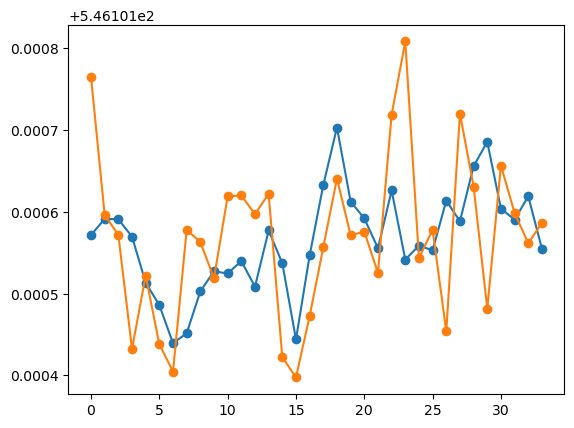

In [6]:
plt.figure()
plt.plot(np.array(fitted_f0), '-o')
plt.plot(f0_list, '-o')
plt.show()

In [7]:
print(np.mean(fitted_f0)-np.mean(f0_list))
print(np.mean(f0_list))
print(np.std(fitted_f0))
print(np.std(f0_list))

-4.081853489878995e-06
546.1015688872425
6.12203075382093e-05
9.687005700718012e-05


In [88]:
np.linspace(0,100,100)

array([  0.        ,   1.01010101,   2.02020202,   3.03030303,
         4.04040404,   5.05050505,   6.06060606,   7.07070707,
         8.08080808,   9.09090909,  10.1010101 ,  11.11111111,
        12.12121212,  13.13131313,  14.14141414,  15.15151515,
        16.16161616,  17.17171717,  18.18181818,  19.19191919,
        20.2020202 ,  21.21212121,  22.22222222,  23.23232323,
        24.24242424,  25.25252525,  26.26262626,  27.27272727,
        28.28282828,  29.29292929,  30.3030303 ,  31.31313131,
        32.32323232,  33.33333333,  34.34343434,  35.35353535,
        36.36363636,  37.37373737,  38.38383838,  39.39393939,
        40.4040404 ,  41.41414141,  42.42424242,  43.43434343,
        44.44444444,  45.45454545,  46.46464646,  47.47474747,
        48.48484848,  49.49494949,  50.50505051,  51.51515152,
        52.52525253,  53.53535354,  54.54545455,  55.55555556,
        56.56565657,  57.57575758,  58.58585859,  59.5959596 ,
        60.60606061,  61.61616162,  62.62626263,  63.63